<html> <h1 style="font-style:bold; color:blue;"> Neural Computing and Deep Learning </h1> </html>

<html> <h1 style="font-style:italic; color:blue;"> Week-12 </h1> </html>

<html> <h2 style="font-style:italic; color:blue;"> Attention Networks </21> </html>

The tutorial will cover the following:

* Preparing a simple dataset for time series forecasting
* How to use a network built via SimpleRNN for time series forecasting
* Adding a custom attention layer to the SimpleRNN network

_________![image.png](attachment:0ad58c9b-2c05-4e8f-b456-56365c0e007f.png)

In [1]:
from pandas import read_csv
import numpy as np

import tensorflow as tf
from tensorflow import keras

from keras import Model
from tensorflow.keras.layers import Layer
from keras.layers import Input, Dense, SimpleRNN

from sklearn.preprocessing import MinMaxScaler

from keras.models import Sequential
from keras.metrics import mean_squared_error

print(tf.__version__)

2.20.0


### The Dataset

We will create a fibonacci sequence dataset for our purpose. In Fibonacci sequence, one number is constructed from the previous two numbers. The first 10 numbers of the sequence are shown below:

0, 1, 1, 2, 3, 5, 8, 13, 21, 34, …


When given the previous ‘t’ numbers, can you get a machine to accurately reconstruct the next number? This would mean discarding all the previous inputs except the last two and performing the correct operation on the last two numbers.

For this tutorial, you’ll construct the training examples from t time steps and use the value at t+1 as the target. For example, if t=3, then the training examples and the corresponding target values would look as follows:


![image.png](attachment:image.png)

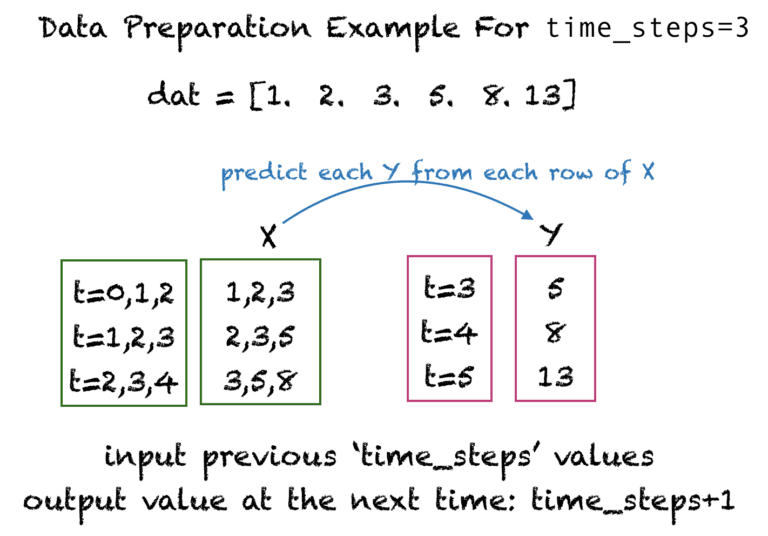

![image.png](attachment:image.png)

The Fibonacci spiral: an approximation of the **golden spiral** created by drawing circular arcs connecting the opposite corners of squares in the Fibonacci tiling

### Data preprocessing

_____________________![image.png](attachment:8d917c7c-28cf-41b6-8242-3dc62a9d37f5.png)

In [2]:
def get_fib_seq(n, scale_data=True):
    # Get the Fibonacci sequence
    seq = np.zeros(n)
    fib_n1 = 0.0
    fib_n = 1.0
    for i in range(n):

        # Create the Fibonacci sequence. Store the sequence in a numpy array 'seq'
        seq[i] = fib_n1 + fib_n
        fib_n1 = fib_n
        fib_n = seq[i]

    scaler = []
    if scale_data:
        scaler = MinMaxScaler(feature_range=(0, 1))
        seq = np.reshape(seq, (n, 1))
        seq = scaler.fit_transform(seq).flatten()
    return seq, scaler

#### Hint:

You can copy blocks of code in the cells above and cells from previous weeks of practice sessions.

Some are easy enough to copy, some need to be slightly modified. This can speed up your code creation.

In [ ]:
# Check if the function works correctly:
# Copy the previous cell, change the function name and add fib_n

________________________![image.png](attachment:18cddcac-477d-4e87-8b99-6dcacd5036d9.png)

In [3]:
def get_fib_seq_check(n, scale_data=True):
    # Get the Fibonacci sequence
    seq = np.zeros(n)
    fib_n1 = 0.0
    fib_n = 1.0
    for i in range(n):
        seq[i] = fib_n1 + fib_n
        fib_n1 = fib_n
        fib_n = seq[i]
    scaler = []
    if scale_data:
        scaler = MinMaxScaler(feature_range=(0, 1))
        seq = np.reshape(seq, (n, 1))
        seq = scaler.fit_transform(seq).flatten()
    return seq, scaler, fib_n    # added the last member of the Fibonacci sequence

_________________![image.png](attachment:db321006-92cc-4c45-9708-928ab15601de.png)

In [4]:
n = 4
dat, scaler, fib_N = get_fib_seq_check(n)
print('seq_normalised =', dat, '\n'
      # math expression inverse to the applied normalisation into the interval [0,1]
      'seq             =', dat*(fib_N-1)+1)

seq_normalised = [0.   0.25 0.5  1.  ] 
seq             = [1. 2. 3. 5.]


In [5]:
# Your code for the same checking with n=6
n = 6
dat, scaler, fib_N = get_fib_seq_check(n)
print('seq_normalised =', dat, '\n'
      'seq             =', dat*(fib_N-1)+1)


seq_normalised = [0.         0.08333333 0.16666667 0.33333333 0.58333333 1.        ] 
seq             = [ 1.  2.  3.  5.  8. 13.]


In [6]:
# Your code for the same checking with n=8

n = 8
dat, scaler, fib_N = get_fib_seq_check(n)
print('seq_normalised =', dat, '\n'
      'seq             =', dat*(fib_N-1)+1)


seq_normalised = [0.         0.03030303 0.06060606 0.12121212 0.21212121 0.36363636
 0.60606061 1.        ] 
seq             = [ 1.  2.  3.  5.  8. 13. 21. 34.]


In [7]:
# Your code for the same checking with n=10

n = 10
dat, scaler, fib_N = get_fib_seq_check(n)
print('seq_normalised =', dat, '\n'
      'seq             =', dat*(fib_N-1)+1)


seq_normalised = [0.         0.01136364 0.02272727 0.04545455 0.07954545 0.13636364
 0.22727273 0.375      0.61363636 1.        ] 
seq             = [ 1.  2.  3.  5.  8. 13. 21. 34. 55. 89.]


___________________![image.png](attachment:7e618c91-f0e5-4de1-ba94-a64fa41371ef.png)

In [8]:
scaler

MinMaxScaler()

MinMaxScaler()

### The following function transforms the fibonacci sequence into training and test dataset.

X and Y looks like the following. From X and Y, we create training and test dataset.


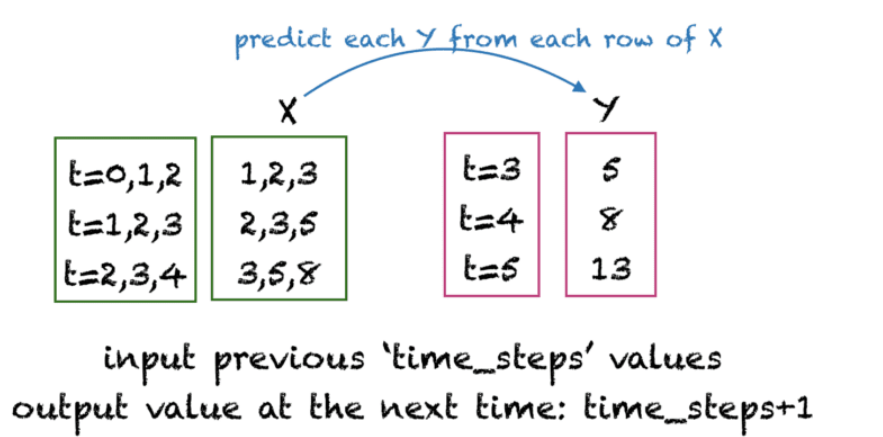

In [9]:
def get_fib_XY(total_fib_numbers, time_steps, train_percent, scale_data=True):
    dat, scaler = get_fib_seq(total_fib_numbers, scale_data)    # Loading the dataset.


    Y_ind = np.arange(time_steps, len(dat), 1)
    Y = dat[Y_ind]
    rows_x = len(Y)
    X = dat[0:rows_x]
    for i in range(time_steps-1):
        temp = dat[i+1:rows_x+i+1]
        X = np.column_stack((X, temp))

    rand = np.random.RandomState(seed=13)
    idx = rand.permutation(rows_x)
    split = int(train_percent*rows_x)
    train_ind = idx[0:split]
    test_ind = idx[split:]
    trainX = X[train_ind]
    trainY = Y[train_ind]
    testX = X[test_ind]
    testY = Y[test_ind]
    trainX = np.reshape(trainX, (len(trainX), time_steps, 1))
    testX = np.reshape(testX, (len(testX), time_steps, 1))

    return trainX, trainY, testX, testY, scaler

_________________![image.png](attachment:f6c95298-4108-4f3d-a7bd-b411e900a952.png)

In [10]:
get_fib_XY(8,3,0.8)

(array([[[0.03030303],
         [0.06060606],
         [0.12121212]],
 
        [[0.12121212],
         [0.21212121],
         [0.36363636]],
 
        [[0.21212121],
         [0.36363636],
         [0.60606061]],
 
        [[0.        ],
         [0.03030303],
         [0.06060606]]]),
 array([0.21212121, 0.60606061, 1.        , 0.12121212]),
 array([[[0.06060606],
         [0.12121212],
         [0.21212121]]]),
 array([0.36363636]),
 MinMaxScaler())

In [ ]:
#np.column_stack?

In [ ]:
#np.random.RandomState.permutation?

### In the following code, we test the performance with the help of a simple RNN.


#### Set up parameters

__________________![image.png](attachment:2c3fc454-be8a-44bc-bddd-bf159366d371.png)

In [11]:
time_steps = 20
hidden_units = 2
epochs = 40

#### Create a traditional RNN network

______________![image.png](attachment:b88e1fbb-1de4-4825-9870-7ee60b591bff.png)

In [12]:
def create_RNN(hidden_units, dense_units, input_shape, activation):
    model = Sequential()
    model.add(SimpleRNN(hidden_units, input_shape=input_shape, activation=activation[0]))
    model.add(Dense(units=dense_units, activation=activation[1]))
    model.compile(loss='mse', optimizer='adam')
    return model

In [13]:
model_RNN = create_RNN(hidden_units=hidden_units, dense_units=1, input_shape=(time_steps,1),activation=['tanh','tanh'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


![image.png](attachment:87ecc6c6-cdc0-4f5f-9fbf-9d5f1d482525.png)

##### tf.keras.activations.tanh

https://www.tensorflow.org/api_docs/python/tf/keras/activations/tanh

In [14]:
model_RNN.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11 (44.00 B)

 Trainable params: 11 (44.00 B)

 Non-trainable params: 0 (0.00 B)

________________________![image.png](attachment:6def3a3d-1d23-428e-bfdc-599c05882d55.png)

In [15]:
trainX,trainY,testX,testY,scaler = get_fib_XY(1200,time_steps,0.7)

#### Train the network

_____________________![image.png](attachment:fdf0c280-b340-494d-a303-7662c76ee97c.png)

In [16]:
history = model_RNN.fit(trainX, trainY,epochs=epochs,batch_size=1,verbose=1)

Epoch 1/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 2.2919e-04
Epoch 2/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2.2780e-04
Epoch 3/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.7381e-04
Epoch 4/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.5125e-04
Epoch 5/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.3922e-04
Epoch 6/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.2789e-04
Epoch 7/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.2341e-04
Epoch 8/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.1096e-04
Epoch 9/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.0684e-04
Epoch 10/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.0315e-04
Epoch 11/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.0099e-04
Epoch 12/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.0275e-04
Epoch 13/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 9.0965e-05
Epoch 14/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 8.7437e-05
E

____________________![image.png](attachment:63ee9395-7301-4020-8459-f18c59469e89.png)

In [17]:
import matplotlib.pyplot as plt
%matplotlib inline

#### Hint:

You can copy blocks of code in the cells above and cells from previous weeks of practice sessions.

Some are easy enough to copy, some need to be slightly modified. This can speed up your code creation.

___________________![image.png](attachment:0906917e-d0bd-4f2f-b06b-3ab1a64df7d0.png)

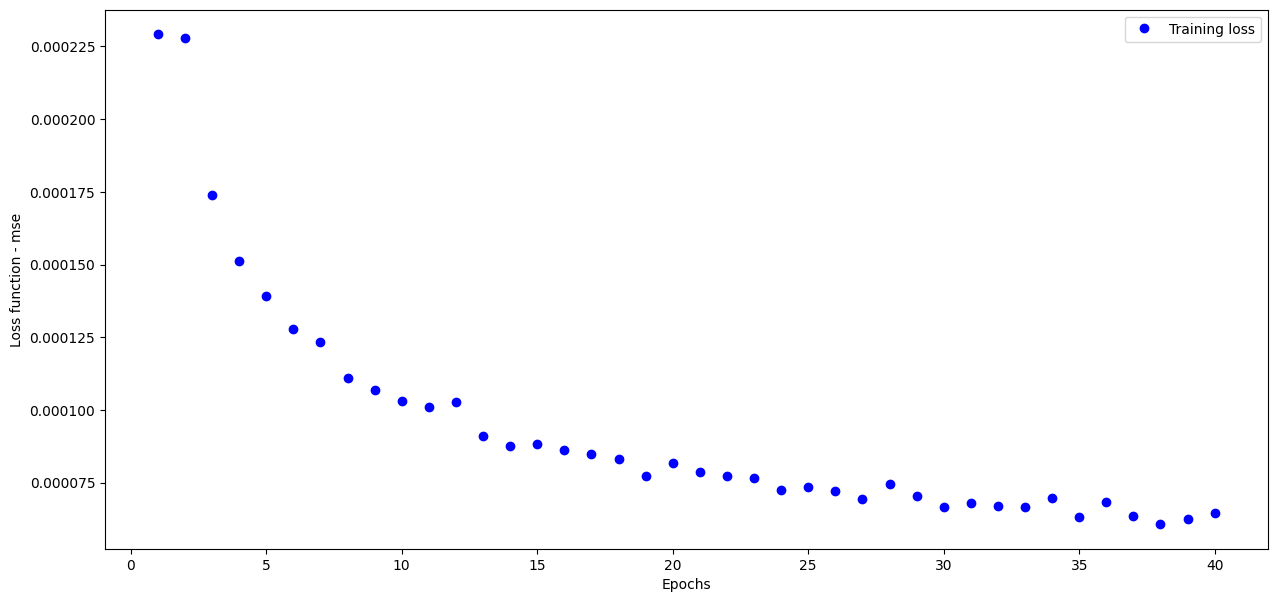

In [18]:
history_dict = history.history

losses = history_dict['loss']
Epochs = range(1, len(losses) + 1)

plt.figure(num=1, figsize=(15,7))
plt.plot(Epochs, losses, 'bo', label='Training loss')

plt.xlabel('Epochs')
plt.ylabel('Loss function - mse')
plt.legend()
plt.show()

#### Evalute model

____________________![image.png](attachment:704c6239-7252-4312-bf39-7787d8022c14.png)

In [19]:
train_mse = model_RNN.evaluate(trainX,trainY)
test_mse = model_RNN.evaluate(testX,testY)

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.4231e-05
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 2.7102e-05


#### Print train and test error metrics

__________________![image.png](attachment:2ef16392-7c84-4b09-b6e0-3b3da59bfd22.png)

In [20]:
print("Train set MSE = ", train_mse)
print("Test set MSE = ", test_mse)

Train set MSE =  5.423115362646058e-05
Test set MSE =  2.7102276362711564e-05


### The following code creates an attention layer. You need to understand each line to know how an attention layer can be created.


_____________________![image.png](attachment:71d7c411-79dc-4192-88e6-9173000987a8.png)

In [21]:
@tf.keras.utils.register_keras_serializable()

class attention(Layer):
    def __init__(self, **kwargs):
        super(attention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight', shape=(input_shape[-1], 1),
                                initializer='random_normal', trainable=True)
        self.b = self.add_weight(name='attention_bias', shape=(input_shape[1], 1),
                                initializer='zeros', trainable=True)
        super(attention, self).build(input_shape)

    def call(self, x):
        e = tf.tanh(tf.matmul(x, self.W) + self.b)
        e = tf.squeeze(e, axis=-1)
        alpha = tf.nn.softmax(e)
        alpha = tf.expand_dims(alpha, axis=-1)
        context = x * alpha
        context = tf.reduce_sum(context, axis=1)
        return context

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])

### The following code develops an RNN with an attention layer to predict the Fibonacci sequence.



In [22]:
time_steps   = 20
hidden_units = 4
epochs       = 53 (SID ends in 13)
patience     = 13

print(f'time_steps   = {time_steps}')
print(f'hidden_units = {hidden_units}')
print(f'epochs       = {epochs}')
print(f'patience     = {patience}')

time_steps   = 20
hidden_units = 4
epochs       = 53
patience     = 13


In [23]:
trainX,trainY,testX,testY,scaler = get_fib_XY(1200,time_steps,0.7)

________________________![image.png](attachment:6e69b52b-48d7-4659-be59-e8002755800c.png)

In [24]:
def create_RNN_with_attention(hidden_units, dense_units, input_shape, activation):
    x = Input(shape=input_shape)
    RNN_layer = SimpleRNN(hidden_units, return_sequences=True, activation=activation)(x)

    attention_layer = attention()(RNN_layer)

    outputs = Dense(dense_units, trainable=True, activation=activation)(attention_layer)
    model = Model(x, outputs)
    model.compile(loss='mse', optimizer='adam')
    return model

________________![image.png](attachment:bcd5cc9e-72bb-461e-bd3d-d31961d0c619.png)

In [25]:
model_attention = create_RNN_with_attention(hidden_units=hidden_units, dense_units=1,
                                            input_shape=(time_steps, 1), activation='tanh')

In [26]:
model_attention.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 20, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 20, 4)          │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (attention)           │ (None, 4)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53 (212.00 B)

 Trainable params: 53 (212.00 B)

 Non-trainable params: 0 (0.00 B)

In [27]:
history_2 = model_attention.fit(trainX, trainY,
                                epochs=epochs,
                                batch_size=1,
                                validation_data=(testX, testY))

Epoch 1/53
826/826 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 2/53
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 3/53
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 4/53
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0012 - val_loss: 9.9562e-04
Epoch 5/53
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0012 - val_loss: 9.3473e-04
Epoch 6/53
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0011 - val_loss: 8.3114e-04
Epoch 7/53
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 9.8970e-04 - val_loss: 7.4182e-04
Epoch 8/53
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 8.8121e-04 - val_loss: 6.2200e-04
Epoch 9/53
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 7.8262e-04 - val_loss: 5.2628e-04
Epoch 10/53
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 6.6771e-04 - val_loss: 4.3027e-04
Epoch 11/53
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 5.7067e-04 - val_loss: 3.2371e-04


#### Hint:

You can copy blocks of code in the cells above and cells from previous weeks of practice sessions.

Some are easy enough to copy, some need to be slightly modified. This can speed up your code creation.


_______________________![image.png](attachment:1b1f1396-b1ab-4e3f-9305-97926a7f8442.png)

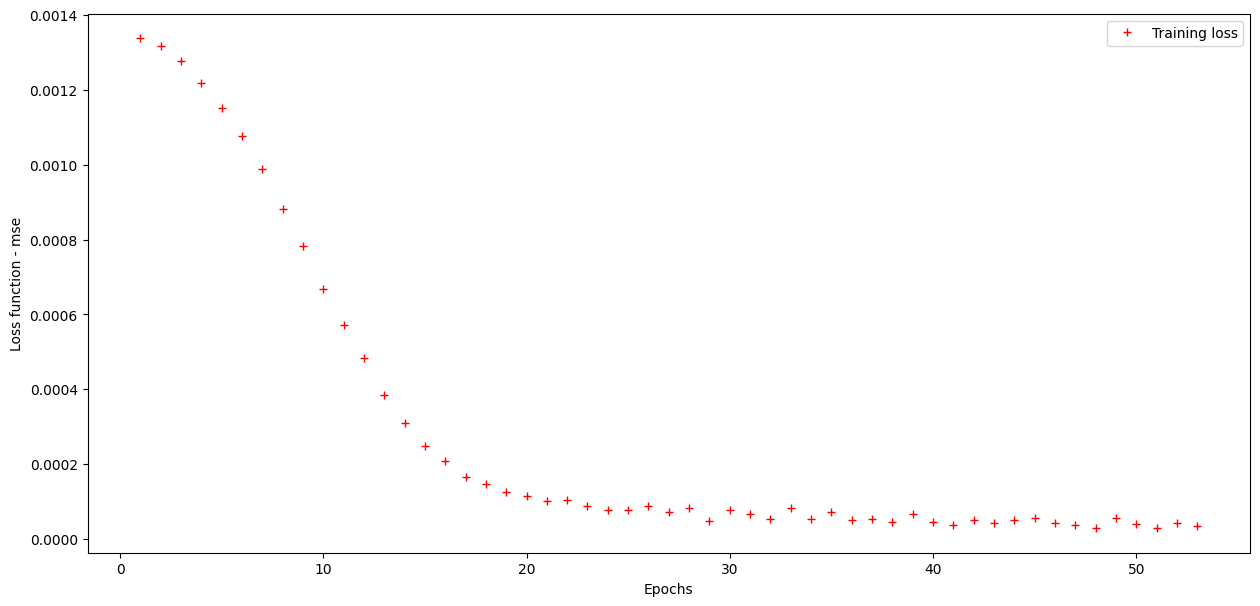

In [28]:
history_dict = history_2.history

losses = history_dict['loss']
Epochs = range(1, len(losses) + 1)

plt.figure(num=1, figsize=(15,7))
plt.plot(Epochs, losses, 'r+', label='Training loss')

plt.xlabel('Epochs')
plt.ylabel('Loss function - mse')
plt.legend()
plt.show()

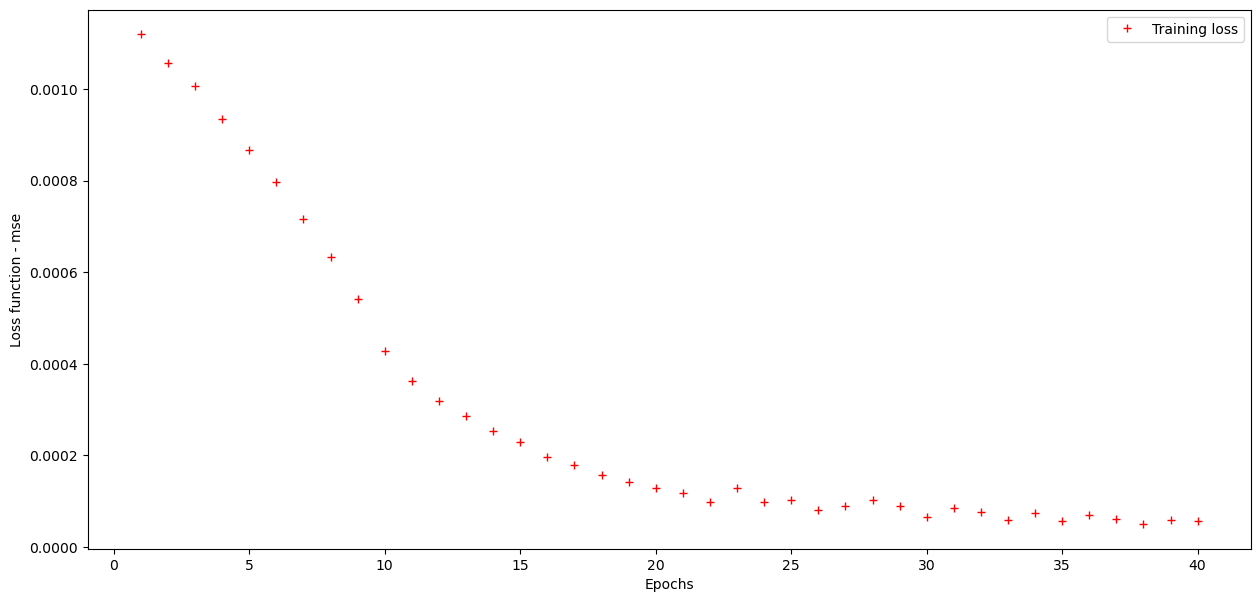

In [29]:
# Evaluate attention model on training set
train_mse_attn = mean_squared_error(trainY, model_attention.predict(trainX).flatten()).numpy()

# Evaluate the attention model on the test set
test_mse_attn = mean_squared_error(testY, model_attention.predict(testX).flatten()).numpy()

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


In [30]:
# print train error metric
print("Attention Train set MSE = ", train_mse_attn)

# print test error metric
print("Attention Test set MSE = ", test_mse_attn)

Attention Train set MSE =  5.3136282e-05
Attention Test set MSE =  6.0257546e-05


In [ ]:
# Draw both loss functions' graphs together

________________________![image.png](attachment:74fcb146-ece0-40d3-8da7-5fe505256c97.png)

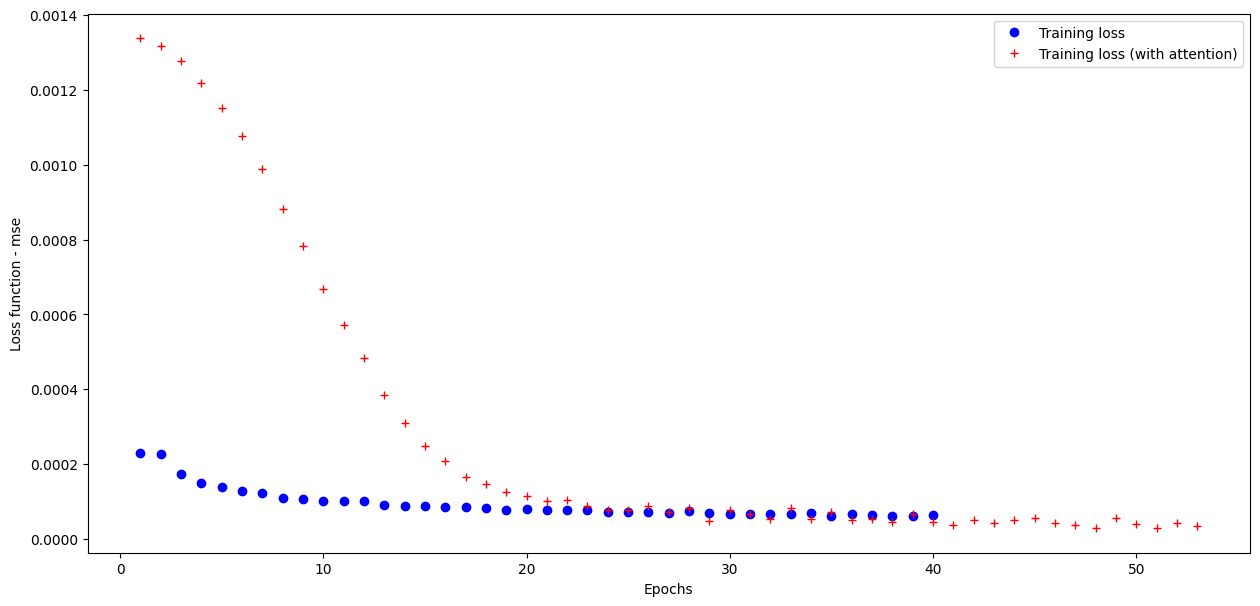

In [31]:
history_dict_1 = history.history
history_dict_2 = history_2.history

losses_1 = history_dict_1['loss']
losses_2 = history_dict_2['loss']

Epochs_1 = range(1, len(losses_1) + 1)
Epochs_2 = range(1, len(losses_2) + 1)
plt.figure(num=1, figsize=(15,7))

plt.plot(Epochs_1, losses_1, 'bo', label='Training loss')
plt.plot(Epochs_2, losses_2, 'r+', label='Training loss (with attention)')

plt.xlabel('Epochs')
plt.ylabel('Loss function - mse')
plt.legend()
plt.show()

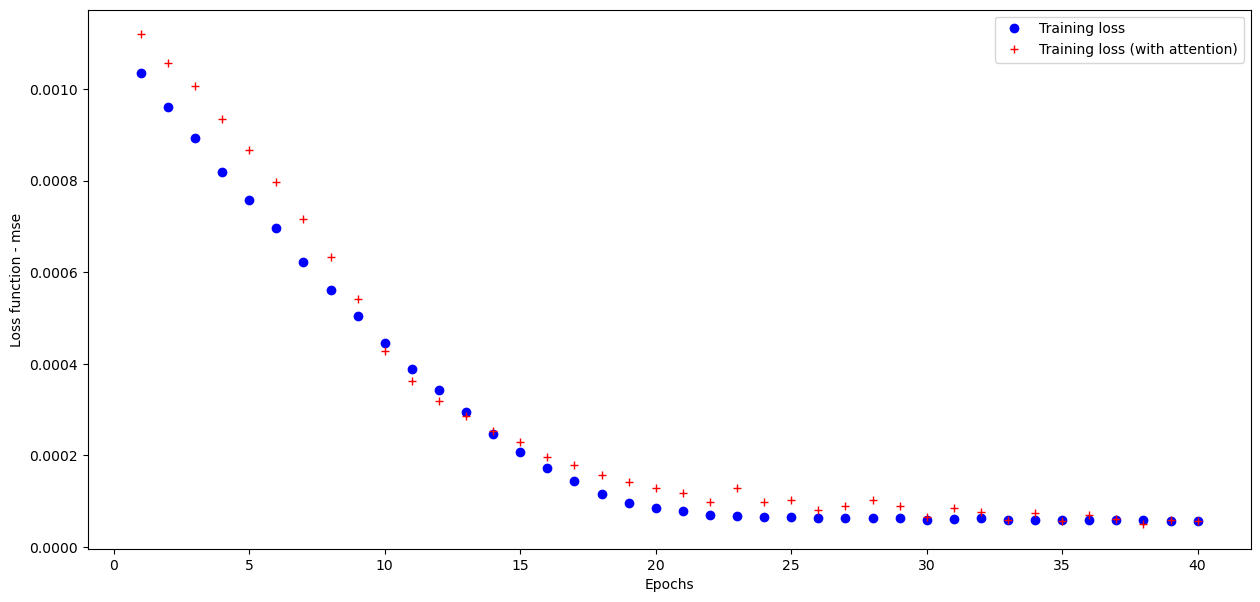

### Plot the train and test MSE performance for the 'Simple RNN' and 'RNN with an attention layer'.


_________________![image.png](attachment:83d9133a-4654-451e-9f28-f0b7c028c16e.png)

In [34]:
import pandas as pd

_______________________![image.png](attachment:b72b208e-2e1b-41a3-9588-ac2a8cc4c0b5.png)

In [35]:

ErrorMetrics = [ [4.628741226042621e-05, 2.7580872483667918e-05],
                 [3.645733158919029e-05, 2.13204857573146e-05]
               ]

ErrorMetrics

[[4.628741226042621e-05, 2.7580872483667918e-05],
 [3.645733158919029e-05, 2.13204857573146e-05]]

____________![image.png](attachment:ccfec9cf-53db-49be-a7df-d1f1bd9283bc.png)

In [36]:
ErrorMetrics_pd = pd.DataFrame(ErrorMetrics)
ErrorMetrics_pd.columns = ['Train', 'Test']
ErrorMetrics_pd.index = ['Simple RNN', 'RNN with an attention layer']
ErrorMetrics_pd

,Train,Test
Simple RNN,0.000046,0.000028
RNN with an attention layer,0.000036,0.000021


In [ ]:
## MSE performance histogram

__________________![image.png](attachment:829c3328-45a7-483c-bf5a-2def8578093f.png)

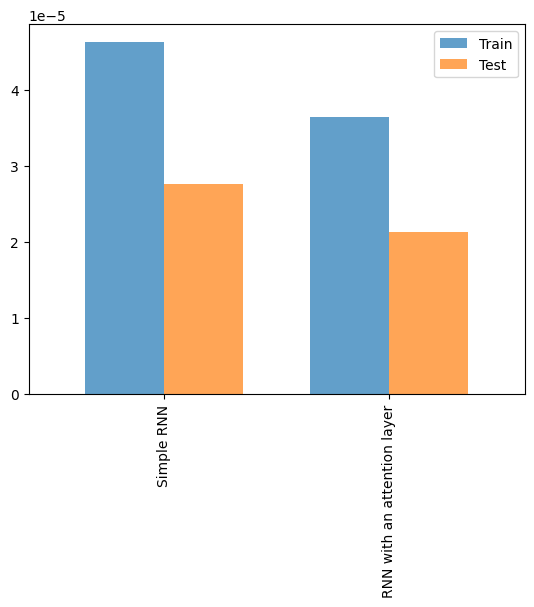

In [37]:
ErrorMetrics_pd.plot.bar(width=0.7, alpha=0.7)
plt.show()

# Lab Logbook Requirement:

<html> <h3 style="; color:blue;">

1) Modify the training parameter of the RNN with an attention layer model using the following formulas:

Modify the number of epochs:
Z + 50
, where your SID is: XXXXXXZ

Use EarlyStopping() and ModelCheckpoint() function to save the best modetl in the file 'best_attention_model.keras'
Modify the patience parameter:
Z + 10
, where your SID is: XXXXXXZ

2) Modify time_steps = 20 and hidden_units = 4
3) Leave other parameters the same as in the practical session
4) Calculate and demonstrate the received loss for train and test datasets
5) Plot the Loss function (MSE) graph during the training process for the 3 models together
6) Please only add to your Lab Logbook print-screens of:
- calculation of your parameters
- your code of using EarlyStopping() and ModelCheckpoint() functions
- your code and training result using model.fit()
- received loss for train and test datasets
- Loss (MSE) graph for the 3 models together during the training process
- performance histogram for train and test loss (MSE) of the 3 models together


</h3> </html>


<html> <h3 style="color:red;">
NOTE: DON'T FORGET TO SAVE AND BACK UP YOUR COMPLETED JUPYTER NOTEBOOK AND LAB LOGBOOK ON GITHUB OR ONEDRIVE.
</h3> </html>

### Test the above model with different parameters, layer size, train and test ratio, and time steps.



__________________![image.png](attachment:f0dddc48-9aa3-4770-aaaf-eba0a9b046a7.png)

In [38]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

________________![image.png](attachment:8e7ae2aa-24b8-420a-930f-d1da020dec6a.png)

In [39]:
# Your code of parameter modification

time_steps   = 20
hidden_units = 4
epochs       = 53
patience     = 13

print(f'time_steps   = {time_steps}')
print(f'hidden_units = {hidden_units}')
print(f'epochs       = {epochs}')
print(f'patience     = {patience}')

time_steps   = 20
hidden_units = 4
epochs       = 53
patience     = 13


In [ ]:
# Continue your code according to the Lab Logbook Requirements ...


In [40]:
trainX_lb, trainY_lb, testX_lb, testY_lb, scaler_lb = get_fib_XY(1200, time_steps, 0.7)

# Build logbook model with hidden_units=4
model_lb = create_RNN_with_attention(hidden_units=hidden_units, dense_units=1,
                                      input_shape=(time_steps, 1), activation='tanh')
model_lb.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 20, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 20, 4)          │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_1 (attention)         │ (None, 4)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53 (212.00 B)

 Trainable params: 53 (212.00 B)

 Non-trainable params: 0 (0.00 B)

In [41]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(monitor='val_loss',
                           patience=patience,
                           restore_best_weights=True,
                           verbose=1)

checkpoint = ModelCheckpoint('best_attention_model.keras',
                              monitor='val_loss',
                              save_best_only=True,
                              verbose=1)


In [42]:
history_lb = model_lb.fit(trainX_lb, trainY_lb,
                           epochs=epochs,
                           batch_size=1,
                           validation_data=(testX_lb, testY_lb),
                           callbacks=[early_stop, checkpoint],
                           verbose=1)


Epoch 1/53
818/826 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0014
Epoch 1: val_loss improved from None to 0.00126, saving model to best_attention_model.keras

Epoch 1: finished saving model to best_attention_model.keras
826/826 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0015 - val_loss: 0.0013
Epoch 2/53
810/826 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3634e-04
Epoch 2: val_loss improved from 0.00126 to 0.00125, saving model to best_attention_model.keras

Epoch 2: finished saving model to best_attention_model.keras
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0015 - val_loss: 0.0012
Epoch 3/53
814/826 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.2572e-04
Epoch 3: val_loss improved from 0.00125 to 0.00122, saving model to best_attention_model.keras

Epoch 3: finished saving model to best_attention_model.keras
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 4/53
821/826 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0011
Epoch 4: val_loss improved from

In [43]:
train_mse_lb = mean_squared_error(trainY_lb,
                model_lb.predict(trainX_lb).flatten()).numpy()
test_mse_lb  = mean_squared_error(testY_lb,
                model_lb.predict(testX_lb).flatten()).numpy()

print(f'Logbook Model — Train MSE : {train_mse_lb:.8f}')
print(f'Logbook Model — Test  MSE : {test_mse_lb:.8f}')


26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Logbook Model — Train MSE : 0.00005079
Logbook Model — Test  MSE : 0.00000041


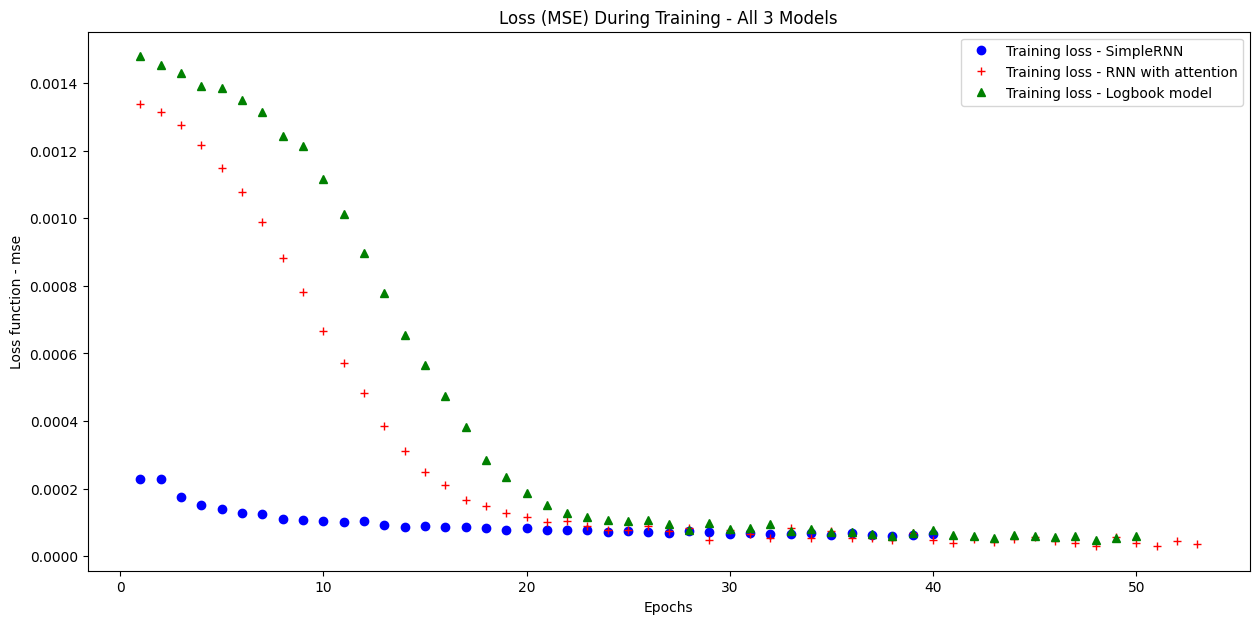

In [44]:
history_dict_1 = history.history
history_dict_2 = history_2.history
history_dict_3 = history_lb.history

losses_1 = history_dict_1['loss']
losses_2 = history_dict_2['loss']
losses_3 = history_dict_3['loss']

Epochs_1 = range(1, len(losses_1) + 1)
Epochs_2 = range(1, len(losses_2) + 1)
Epochs_3 = range(1, len(losses_3) + 1)

plt.figure(num=2, figsize=(15, 7))
plt.plot(Epochs_1, losses_1, 'bo', label='Training loss - SimpleRNN')
plt.plot(Epochs_2, losses_2, 'r+', label='Training loss - RNN with attention')
plt.plot(Epochs_3, losses_3, 'g^', label='Training loss - Logbook model')

plt.xlabel('Epochs')
plt.ylabel('Loss function - mse')
plt.title('Loss (MSE) During Training - All 3 Models')
plt.legend()
plt.show()


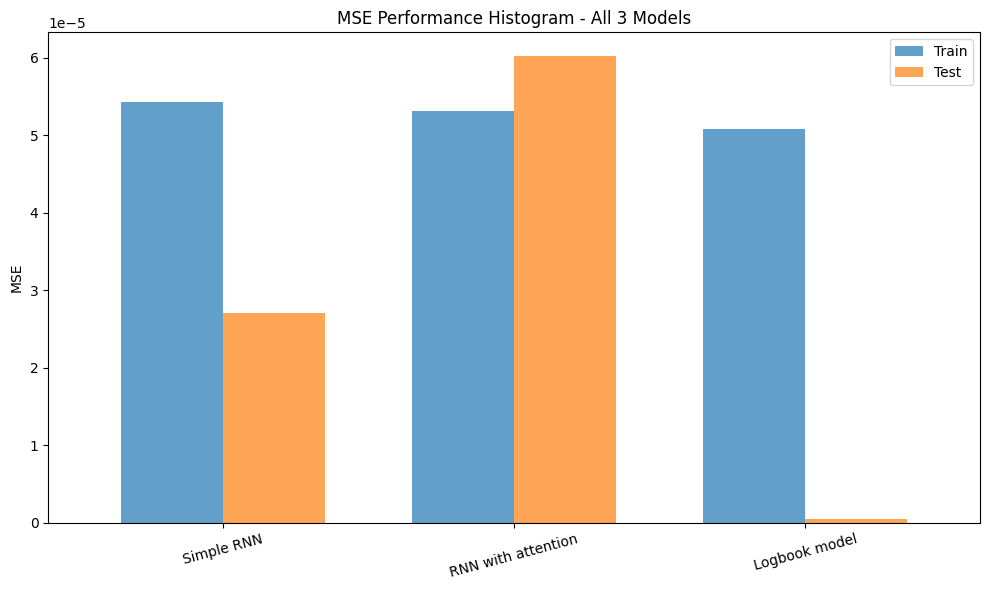

SimpleRNN       — Train: 0.00005423  | Test: 0.00002710
Attn (original) — Train: 0.00005314  | Test: 0.00006026
Attn (logbook)  — Train: 0.00005079  | Test: 0.00000041


In [45]:
ErrorMetrics_3 = [
    [train_mse,      test_mse],
    [train_mse_attn, test_mse_attn],
    [train_mse_lb,   test_mse_lb]
]

ErrorMetrics_pd3 = pd.DataFrame(ErrorMetrics_3)
ErrorMetrics_pd3.columns = ['Train', 'Test']
ErrorMetrics_pd3.index   = ['Simple RNN',
                             'RNN with attention',
                             'Logbook model']

ErrorMetrics_pd3.plot.bar(width=0.7, alpha=0.7, figsize=(10, 6))
plt.title('MSE Performance Histogram - All 3 Models')
plt.ylabel('MSE')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print(f'SimpleRNN       — Train: {train_mse:.8f}  | Test: {test_mse:.8f}')
print(f'Attn (original) — Train: {train_mse_attn:.8f}  | Test: {test_mse_attn:.8f}')
print(f'Attn (logbook)  — Train: {train_mse_lb:.8f}  | Test: {test_mse_lb:.8f}')